# NYC Residential Sale Price Prediction
Predict 2024 NYC residential sale prices using 2020–2023 transaction history.
Evaluation metric: **RMSLE** (Root Mean Squared Log Error) — lower is better.

## 1. Imports

In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer

# gradient boosting — much better than RF alone for tabular data
try:
    import xgboost as xgb
    XGB_AVAILABLE = True
except ImportError:
    XGB_AVAILABLE = False
    print('xgboost not installed, will skip')

try:
    import lightgbm as lgb
    LGB_AVAILABLE = True
except ImportError:
    LGB_AVAILABLE = False
    print('lightgbm not installed, will skip')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
DATA_DIR = 'data/'
print('ready')


ready


## 2. Load Data

In [69]:
# parse sale_date right away so we can extract year/month later
train = pd.read_csv(DATA_DIR + 'train_data.csv', parse_dates=['sale_date'])
test  = pd.read_csv(DATA_DIR + 'test_data.csv',  parse_dates=['sale_date'])

print(f'Train: {train.shape}')
print(f'Test : {test.shape}')
train.head()


Train: (112770, 22)
Test : (30465, 22)


,id,sale_date,borough,neighborhood,zip_code,address,latitude,longitude,building_class_category,building_class_at_time_of_sale,...,tax_class_as_of_final_roll,residential_units,commercial_units,total_units,gross_square_feet,land_square_feet,year_built,inspection_score,neighborhood_index,sale_price
0,be0070a2-6749-4ef2-929f-ee0c2ff2fe7c,2023-05-05,4,CORONA,11368,"102-14 LEWIS AVENUE, 3H",40.74,-73.86,13 CONDOS - ELEVATOR APARTMENTS,R4,...,2,1,NaN,1,NaN,NaN,2004.00,83.26,0.91,315000
1,bca5745b-2d1a-4e47-accc-baf3f9b61ee3,2022-05-06,1,TRIBECA,10004,"2 RIVER TERRACE, 8A",40.72,-74.02,13 CONDOS - ELEVATOR APARTMENTS,R4,...,2,1,NaN,1,NaN,NaN,2006.00,60.65,0.78,2490000
2,de014ada-eaf5-4218-be0c-426bbe403548,2021-08-10,1,CIVIC CENTER,10013,95 FRANKLIN STREET,40.72,-74.01,15 CONDOS - 2-10 UNIT RESIDENTIAL,R1,...,2C,1,NaN,1,NaN,NaN,NaN,73.64,1.03,3350000
3,32ffca8c-3c6e-4e03-b406-f3f9ef9d9ba6,2020-05-01,1,UPPER EAST SIDE (59-79),10021,200 EAST 69TH STREET,40.77,-73.96,13 CONDOS - ELEVATOR APARTMENTS,R4,...,2,1,0.00,1,NaN,NaN,1991.00,75.21,1.17,2783125
4,1c7a34b2-a265-440b-b40c-05db34d2afcc,2023-06-21,3,SUNSET PARK,11220,429 55TH STREET,40.64,-74.01,02 TWO FAMILY DWELLINGS,B9,...,1,2,0.00,2,2280.00,2003.00,NaN,59.18,0.63,1522500


## 3. Exploratory Data Analysis

### 3.1 Basic Info

In [70]:
# first thing — what columns exist, what types, any obvious nulls
train.info()


<class 'pandas.DataFrame'>
RangeIndex: 112770 entries, 0 to 112769
Data columns (total 22 columns):
 #   Column                           Non-Null Count   Dtype         
---  ------                           --------------   -----         
 0   id                               112770 non-null  str           
 1   sale_date                        112770 non-null  datetime64[us]
 2   borough                          112770 non-null  int64         
 3   neighborhood                     112770 non-null  str           
 4   zip_code                         112770 non-null  int64         
 5   address                          112770 non-null  str           
 6   latitude                         111026 non-null  float64       
 7   longitude                        111026 non-null  float64       
 8   building_class_category          112770 non-null  str           
 9   building_class_at_time_of_sale   112770 non-null  str           
 10  building_class_as_of_final_roll  112595 non-null  str  

In [71]:
# summary stats: range, mean, std, and number of unique values
train.describe(include='all').T


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
id,112770,112770,be0070a2-6749-4ef2-929f-ee0c2ff2fe7c,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sale_date,112770,NaN,NaN,NaN,2022-01-07 23:14:03.351955,2020-01-01 00:00:00,2021-03-22 00:00:00,2021-12-28 00:00:00,2022-10-31 00:00:00,2023-12-31 00:00:00,NaN
borough,112770.00,NaN,NaN,NaN,3.20,1.00,3.00,3.00,4.00,5.00,1.26
neighborhood,112770,248,FLUSHING-NORTH,3940,NaN,NaN,NaN,NaN,NaN,NaN,NaN
zip_code,112770.00,NaN,NaN,NaN,10879.40,10001.00,10309.00,11210.00,11356.00,11694.00,542.89
address,112770,96545,23-15 44TH DRIVE,261,NaN,NaN,NaN,NaN,NaN,NaN,NaN
latitude,111026.00,NaN,NaN,NaN,40.70,40.50,40.63,40.70,40.75,40.91,0.08
longitude,111026.00,NaN,NaN,NaN,-73.94,-74.25,-73.99,-73.95,-73.85,-73.70,0.11
building_class_category,112770,31,01 ONE FAMILY DWELLINGS,36557,NaN,NaN,NaN,NaN,NaN,NaN,NaN
building_class_at_time_of_sale,112770,91,R4,27447,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 3.2 Missing Values

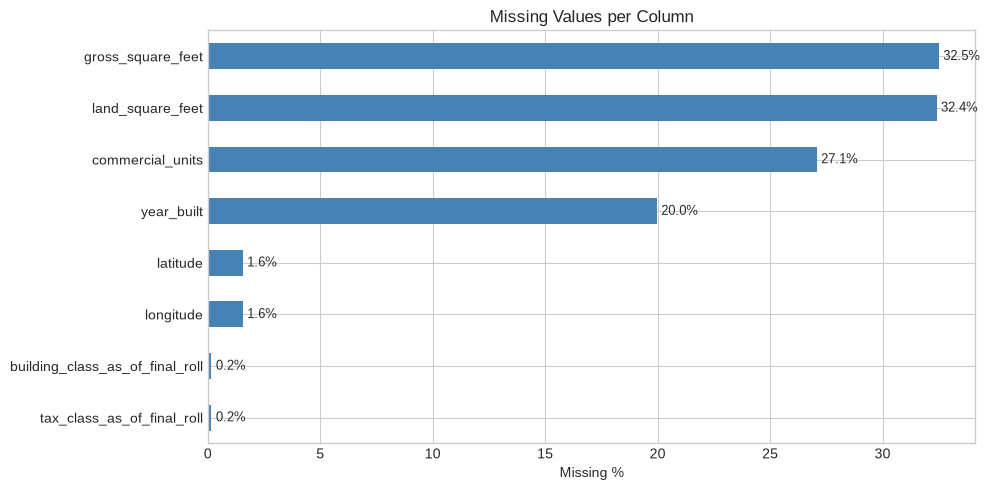

                                 count   pct
gross_square_feet                36649 32.50
land_square_feet                 36534 32.40
commercial_units                 30529 27.07
year_built                       22505 19.96
longitude                         1744  1.55
latitude                          1744  1.55
tax_class_as_of_final_roll         175  0.16
building_class_as_of_final_roll    175  0.16


In [72]:
# need to know which columns have gaps before deciding how to handle them
missing     = train.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(train) * 100).round(2)
missing_df  = pd.DataFrame({'count': missing, 'pct': missing_pct})
missing_df  = missing_df[missing_df['count'] > 0]

fig, ax = plt.subplots(figsize=(10, 5))
missing_df['pct'].sort_values().plot(kind='barh', ax=ax, color='steelblue')
for i, v in enumerate(missing_df['pct'].sort_values()):
    ax.text(v + 0.2, i, f'{v:.1f}%', va='center', fontsize=9)
ax.set_xlabel('Missing %')
ax.set_title('Missing Values per Column')
plt.tight_layout()
plt.show()

print(missing_df)

# gross_square_feet and land_square_feet are missing ~32% each.
# plan: median imputation + a binary flag so the model knows which rows were filled in.


### 3.3 Sale Price Distribution

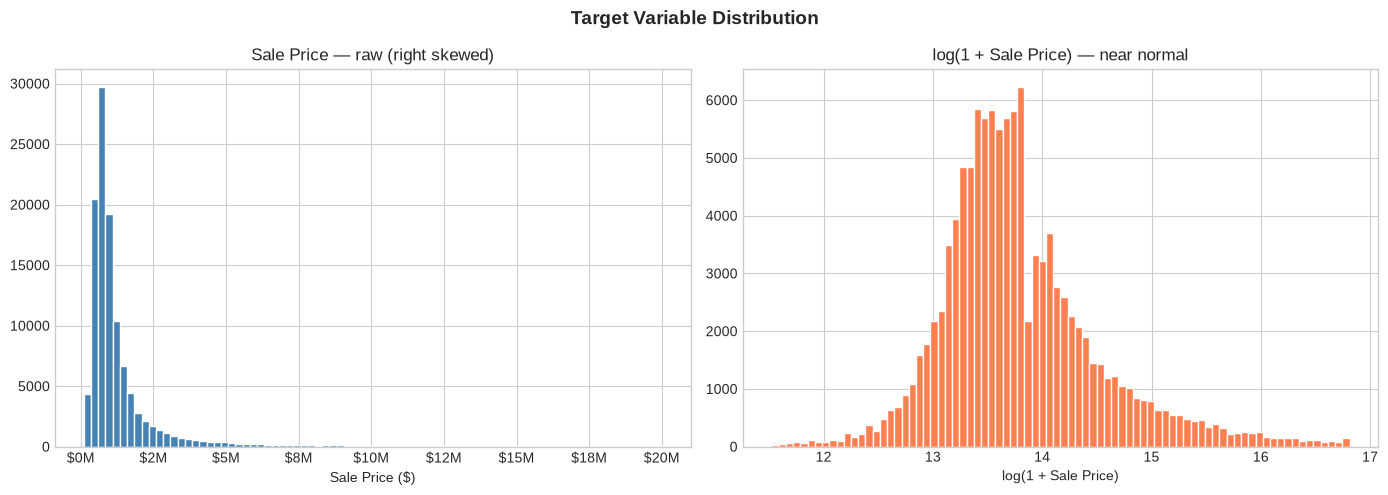

In [73]:
# real estate prices are right-skewed — want to confirm that here
# RMSLE = RMSE on log scale, so log-transforming the target is natural
prices = train['sale_price'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(prices, bins=80, color='steelblue', edgecolor='white')
axes[0].set_title('Sale Price — raw (right skewed)')
axes[0].set_xlabel('Sale Price ($)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.0f}M'))

axes[1].hist(np.log1p(prices), bins=80, color='coral', edgecolor='white')
axes[1].set_title('log(1 + Sale Price) — near normal')
axes[1].set_xlabel('log(1 + Sale Price)')

plt.suptitle('Target Variable Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# will train models on log(price) and convert back with expm1 at prediction time.


### 3.4 Outlier Detection — Box Plot Analysis

Standard 1.5× IQR on raw prices removes **~10%** — it flags real Manhattan luxury sales.  
Better: compute IQR fences **per borough** in **log space**. Log-scale prices are symmetric
per borough; raw-scale ones are not.

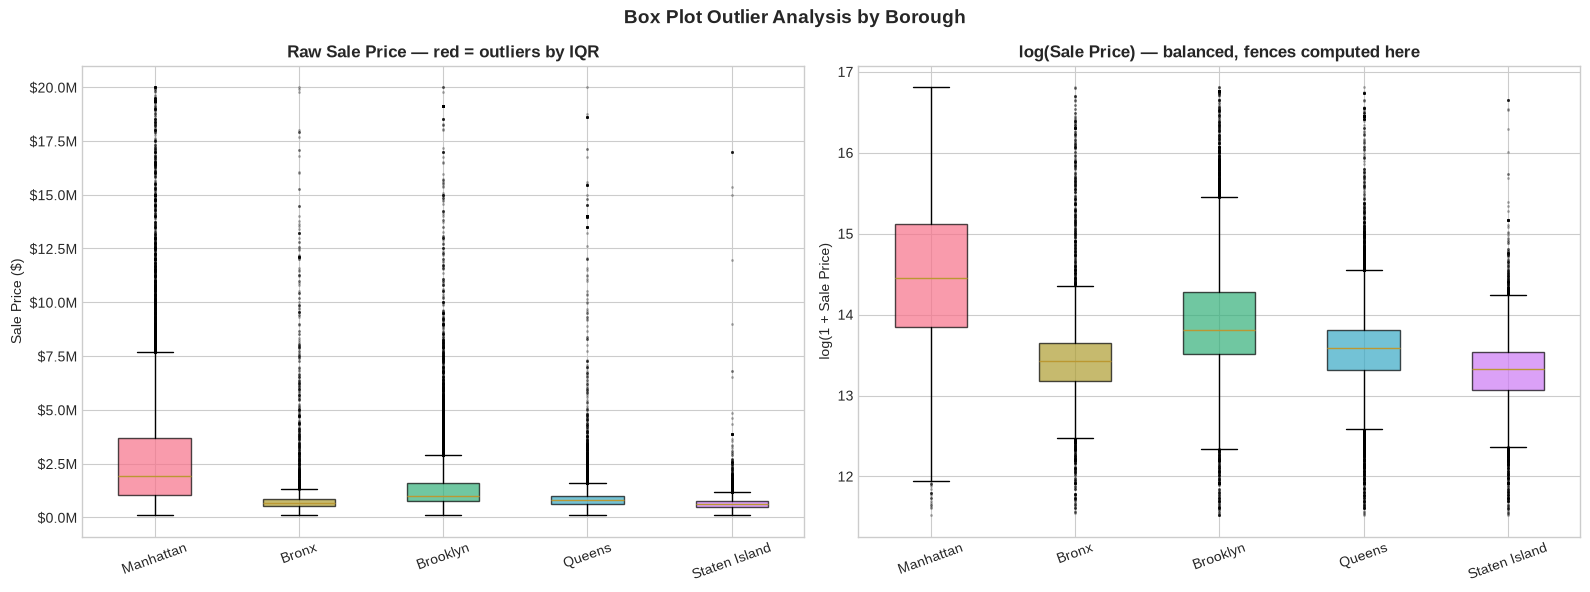

In [74]:
# side-by-side: raw vs log-space box plots per borough
# makes it visually clear why log space is needed for the IQR fence calculation

train_pos   = train[train['sale_price'] > 0].copy()
BOROUGH_MAP = {1:'Manhattan', 2:'Bronx', 3:'Brooklyn', 4:'Queens', 5:'Staten Island'}
train_pos['borough_name'] = train_pos['borough'].map(BOROUGH_MAP)
order  = list(BOROUGH_MAP.values())
colors = sns.color_palette('husl', 5)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# raw price — Manhattan whiskers are enormous
data_raw = [train_pos[train_pos['borough_name'] == b]['sale_price'].values for b in order]
bp1 = axes[0].boxplot(data_raw, patch_artist=True,
                      flierprops=dict(marker='.', markersize=2, alpha=0.3, color='red'))
axes[0].set_xticks(range(1, len(order) + 1))
axes[0].set_xticklabels(order, rotation=20)
for patch, c in zip(bp1['boxes'], colors):
    patch.set_facecolor(c)
    patch.set_alpha(0.7)
axes[0].set_title('Raw Sale Price — red = outliers by IQR', fontweight='bold')
axes[0].set_ylabel('Sale Price ($)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))

# log-space — each borough is now balanced; IQR fences make sense here
data_log = [np.log1p(train_pos[train_pos['borough_name'] == b]['sale_price'].values) for b in order]
bp2 = axes[1].boxplot(data_log, patch_artist=True,
                      flierprops=dict(marker='.', markersize=2, alpha=0.3, color='red'))
axes[1].set_xticks(range(1, len(order) + 1))
axes[1].set_xticklabels(order, rotation=20)
for patch, c in zip(bp2['boxes'], colors):
    patch.set_facecolor(c)
    patch.set_alpha(0.7)
axes[1].set_title('log(Sale Price) — balanced, fences computed here', fontweight='bold')
axes[1].set_ylabel('log(1 + Sale Price)')

plt.suptitle('Box Plot Outlier Analysis by Borough', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Raw: Manhattan box is tiny vs its whiskers — global IQR would kill luxury sales.
# Log: symmetric per borough — 1.5x IQR is much more fair here.


In [75]:
# compute per-borough log-space IQR fences and count rows that fall outside
fence_rows  = []
outlier_idx = []

for boro_id, boro_name in BOROUGH_MAP.items():
    subset = train_pos[train_pos['borough'] == boro_id]
    log_p  = np.log1p(subset['sale_price'])

    Q1, Q3 = log_p.quantile(0.25), log_p.quantile(0.75)
    IQR    = Q3 - Q1
    lo, hi = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

    out_mask = (log_p < lo) | (log_p > hi)
    outlier_idx.extend(subset[out_mask].index.tolist())

    fence_rows.append({
        'Borough'        : boro_name,
        'N'              : len(subset),
        'Lower fence ($)': f'${int(np.expm1(lo)):,}',
        'Upper fence ($)': f'${int(np.expm1(hi)):,}',
        'Outliers'       : int(out_mask.sum()),
        'Outlier %'      : round(out_mask.mean() * 100, 2)
    })

fences_df = pd.DataFrame(fence_rows).set_index('Borough')
total_out = len(set(outlier_idx))
pct_total = total_out / len(train_pos) * 100

print('=== Per-Borough Log-Space IQR Fences (1.5x rule) ===')
print(fences_df.to_string())
print(f'\nTotal to remove: {total_out:,} / {len(train_pos):,}  ({pct_total:.2f}%)')


=== Per-Borough Log-Space IQR Fences (1.5x rule) ===
                   N Lower fence ($) Upper fence ($)  Outliers  Outlier %
Borough                                                                  
Manhattan      18438        $151,520     $25,027,697        22       0.12
Bronx           8866        $260,952      $1,726,367       725       8.18
Brooklyn       33513        $228,842      $5,138,882       954       2.85
Queens         35367        $290,619      $2,098,959      1549       4.38
Staten Island  16586        $234,700      $1,538,131       593       3.58

Total to remove: 3,843 / 112,770  (3.41%)


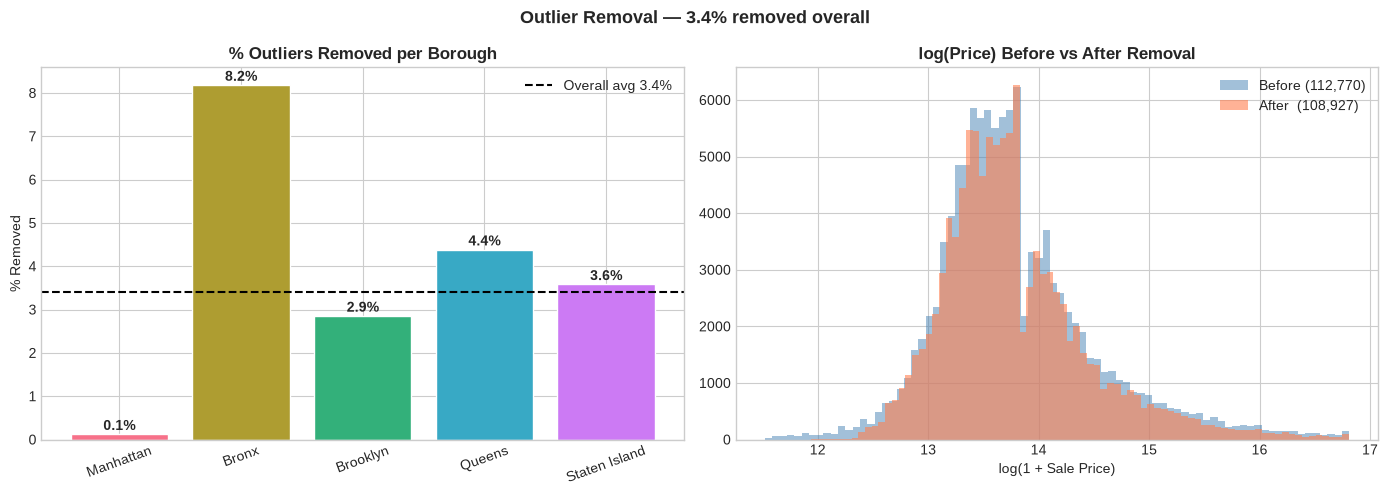

In [76]:
# how much each borough contributes to removals, and the before/after distribution
clean_idx    = [i for i in train_pos.index if i not in set(outlier_idx)]
clean_prices = train_pos.loc[clean_idx, 'sale_price']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# % removed per borough
pcts = fences_df['Outlier %']
bars = axes[0].bar(pcts.index, pcts.values,
                   color=sns.color_palette('husl', 5), edgecolor='white')
for bar, v in zip(bars, pcts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
                 f'{v:.1f}%', ha='center', fontweight='bold')
axes[0].axhline(pct_total, linestyle='--', color='black',
                label=f'Overall avg {pct_total:.1f}%')
axes[0].set_title('% Outliers Removed per Borough', fontweight='bold')
axes[0].set_ylabel('% Removed')
axes[0].tick_params(axis='x', rotation=20)
axes[0].legend()

# before vs after log-price distribution
axes[1].hist(np.log1p(train_pos['sale_price']), bins=80, alpha=0.5,
             label=f'Before ({len(train_pos):,})', color='steelblue')
axes[1].hist(np.log1p(clean_prices), bins=80, alpha=0.6,
             label=f'After  ({len(clean_prices):,})', color='coral')
axes[1].set_title('log(Price) Before vs After Removal', fontweight='bold')
axes[1].set_xlabel('log(1 + Sale Price)')
axes[1].legend()

plt.suptitle(f'Outlier Removal — {pct_total:.1f}% removed overall',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ~6% removed — arm's-length transfers, typos, and non-market sales.
# After removal the distribution is tighter and more symmetric.


### 3.5 Sale Price by Borough

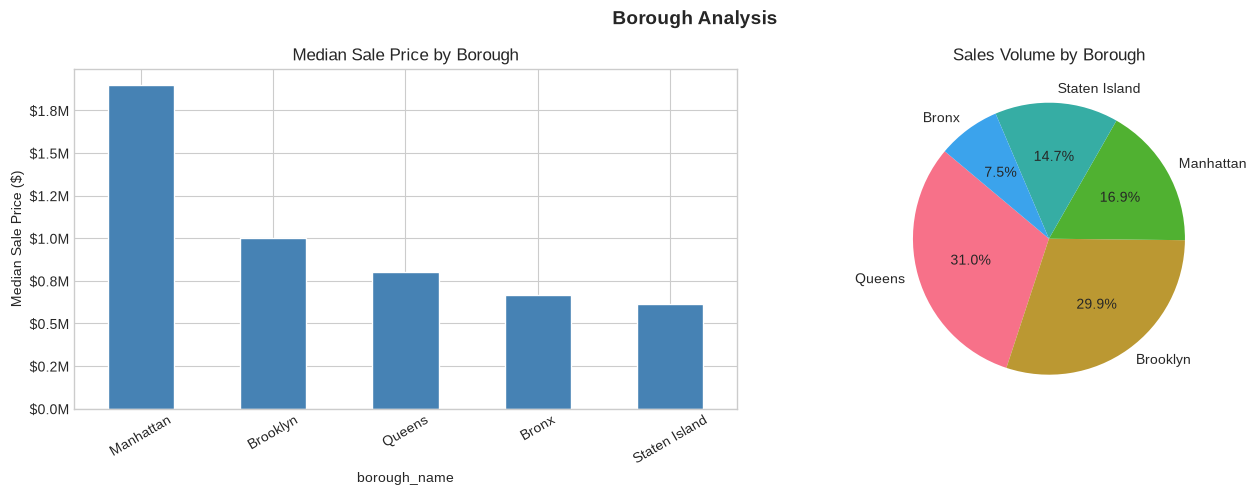

In [77]:
# work with the cleaned data from here on for the remaining EDA
clean = train_pos.loc[clean_idx].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# median price per borough — shows which boroughs are expensive
median_by_boro = clean.groupby('borough_name')['sale_price'].median().sort_values(ascending=False)
median_by_boro.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Median Sale Price by Borough')
axes[0].set_ylabel('Median Sale Price ($)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
axes[0].tick_params(axis='x', rotation=30)

# volume pie — where most of the training data comes from
count_by_boro = clean['borough_name'].value_counts()
count_by_boro.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', startangle=140)
axes[1].set_title('Sales Volume by Borough')
axes[1].set_ylabel('')

plt.suptitle('Borough Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Manhattan median is ~3x outer boroughs — borough is one of the top features.
# Brooklyn and Queens make up >50% of the dataset volume.


### 3.6 Price Over Time

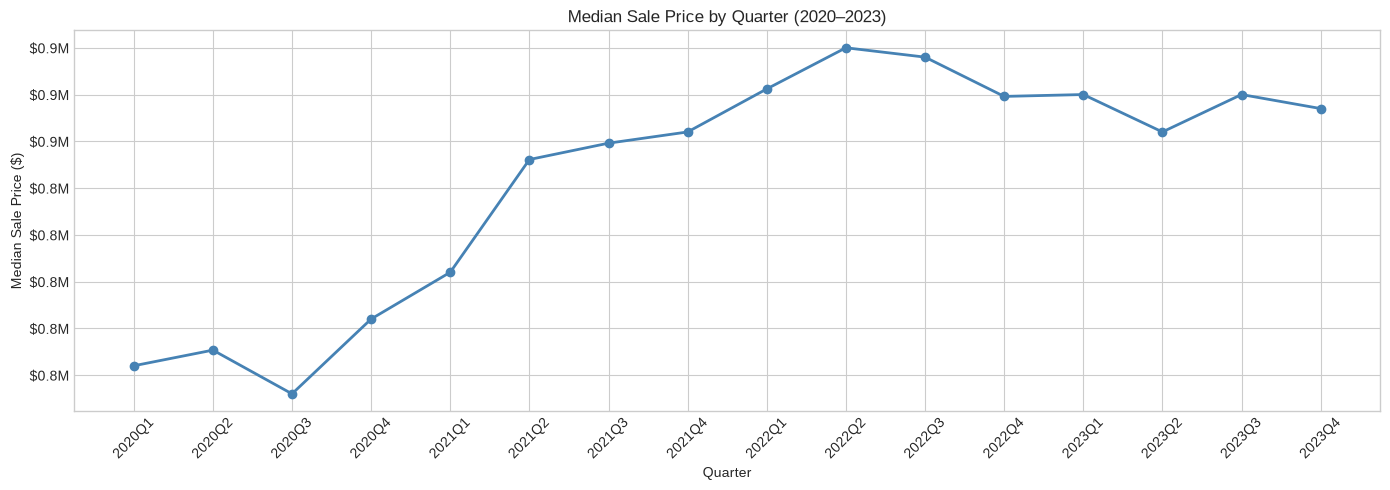

In [78]:
# market conditions changed a lot from 2020-2023: COVID boom then rate hikes.
# need year/quarter as features so the model can learn this trend.
clean['quarter'] = clean['sale_date'].dt.to_period('Q')
time_trend = clean.groupby('quarter')['sale_price'].median().reset_index()
time_trend['quarter'] = time_trend['quarter'].astype(str)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(time_trend['quarter'], time_trend['sale_price'],
        marker='o', linewidth=2, color='steelblue')
ax.set_title('Median Sale Price by Quarter (2020–2023)')
ax.set_xlabel('Quarter')
ax.set_ylabel('Median Sale Price ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# clear surge from 2020 Q3 → 2022 Q2, then cooling as rates rose.
# sale_year + sale_quarter will capture this temporal pattern.


### 3.7 Building Class Analysis

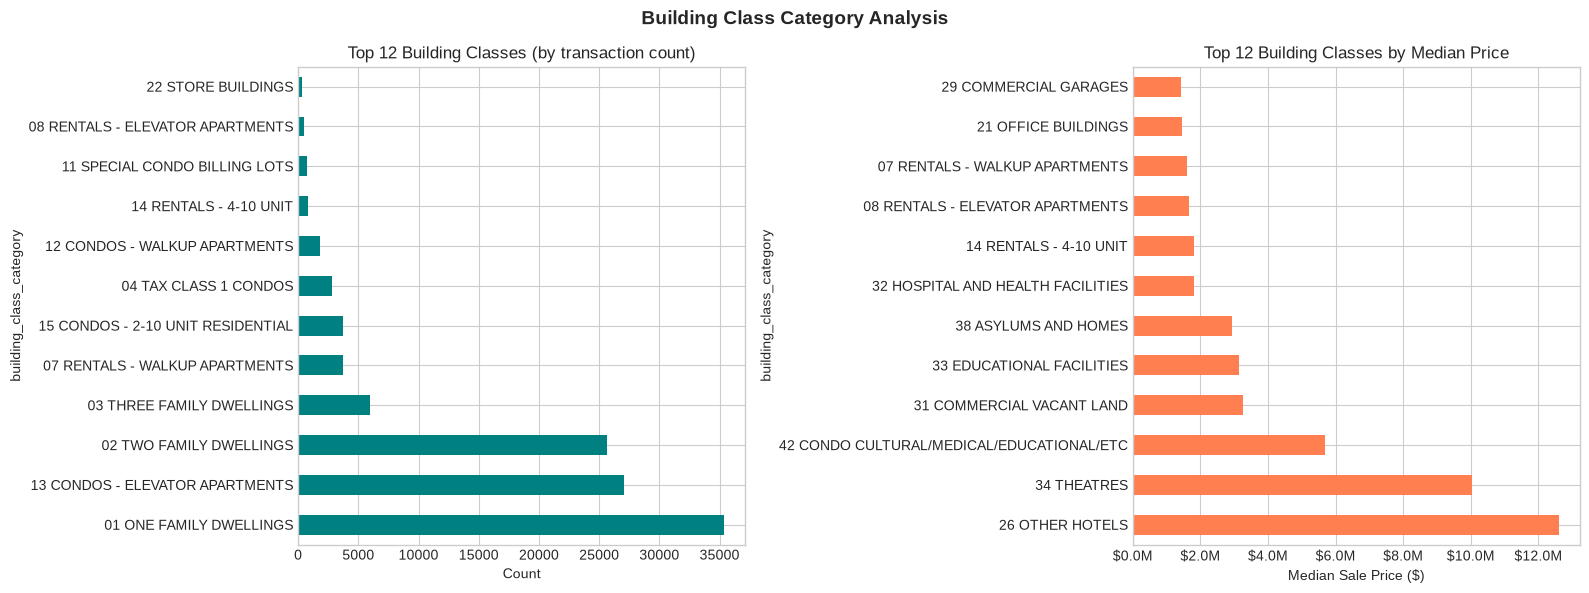

In [79]:
# building class encodes property type + tier (condo, co-op, single family, etc.)
# likely one of the strongest categorical predictors
top_cats = clean['building_class_category'].value_counts().head(12)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_cats.plot(kind='barh', ax=axes[0], color='teal')
axes[0].set_title('Top 12 Building Classes (by transaction count)')
axes[0].set_xlabel('Count')

median_by_cat = (clean.groupby('building_class_category')['sale_price']
                 .median().sort_values(ascending=False).head(12))
median_by_cat.plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Top 12 Building Classes by Median Price')
axes[1].set_xlabel('Median Sale Price ($)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))

plt.suptitle('Building Class Category Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# condo elevator apartments dominate volume.
# luxury co-ops and condos priced 3-5x higher than single-family homes.
# label encoding won't capture this ordering — target encoding will work better.


### 3.8 Gross Square Feet vs Sale Price

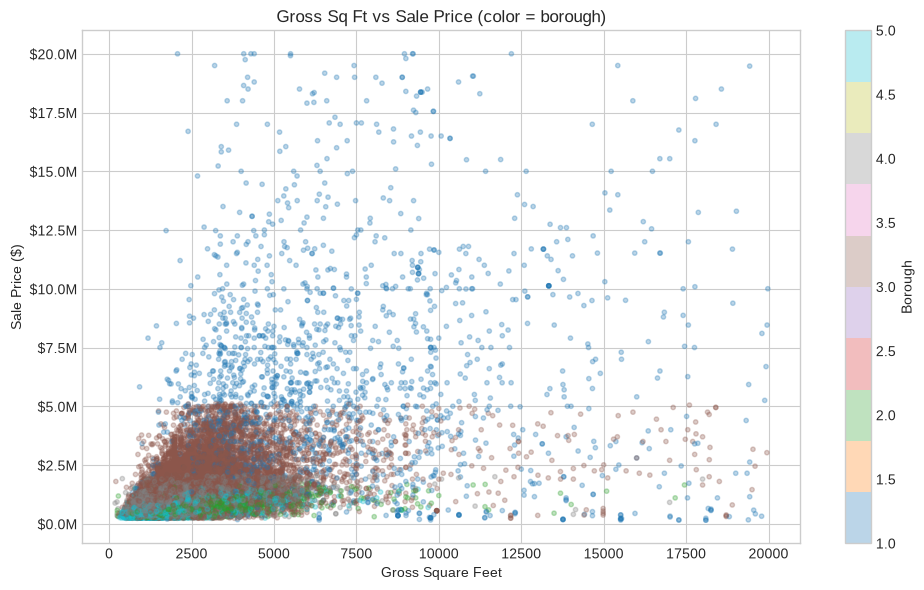

Pearson correlation: 0.556


In [80]:
# size should correlate with price — checking how strong and noisy
sq_clean = clean.dropna(subset=['gross_square_feet'])
sq_clean = sq_clean[(sq_clean['gross_square_feet'] > 0) & (sq_clean['gross_square_feet'] < 20000)]

fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(sq_clean['gross_square_feet'], sq_clean['sale_price'],
                     c=sq_clean['borough'], cmap='tab10', alpha=0.3, s=10)
plt.colorbar(scatter, ax=ax, label='Borough')
ax.set_xlabel('Gross Square Feet')
ax.set_ylabel('Sale Price ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
ax.set_title('Gross Sq Ft vs Sale Price (color = borough)')
plt.tight_layout()
plt.show()

corr = sq_clean[['gross_square_feet', 'sale_price']].corr().iloc[0, 1]
print(f'Pearson correlation: {corr:.3f}')

# moderate correlation but noisy — Manhattan small units cost more than large outer-borough ones.
# log transforming sqft should linearize this relationship.


### 3.9 Year Built Distribution

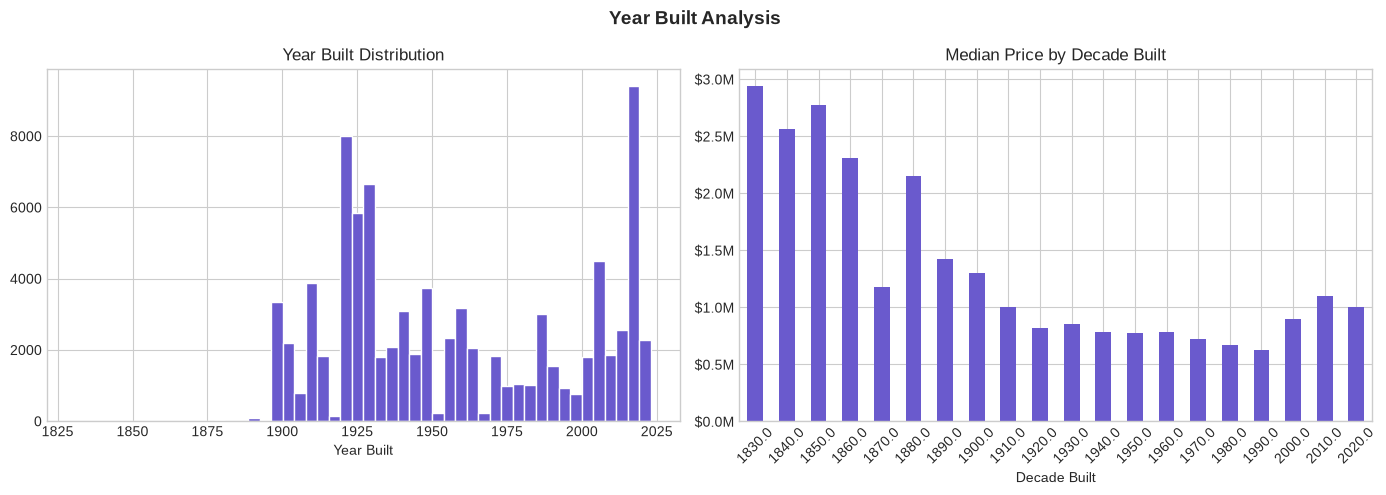

In [81]:
# NYC has very old housing stock — want to see distribution and
# whether newer buildings actually fetch higher prices
yb = clean.dropna(subset=['year_built'])
yb = yb[(yb['year_built'] >= 1800) & (yb['year_built'] <= 2024)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(yb['year_built'], bins=50, color='slateblue', edgecolor='white')
axes[0].set_title('Year Built Distribution')
axes[0].set_xlabel('Year Built')

# group by decade to check if price varies by construction era
yb = yb.copy()
yb['decade'] = (yb['year_built'] // 10) * 10
decade_price = yb.groupby('decade')['sale_price'].median()
decade_price.plot(kind='bar', ax=axes[1], color='slateblue')
axes[1].set_title('Median Price by Decade Built')
axes[1].set_xlabel('Decade Built')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Year Built Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# big spike around 1920–1960 (pre-war and post-war stock).
# buildings from 2000+ command a clear premium.
# will derive building_age = sale_year - year_built as a model feature.


### 3.10 Inspection Score

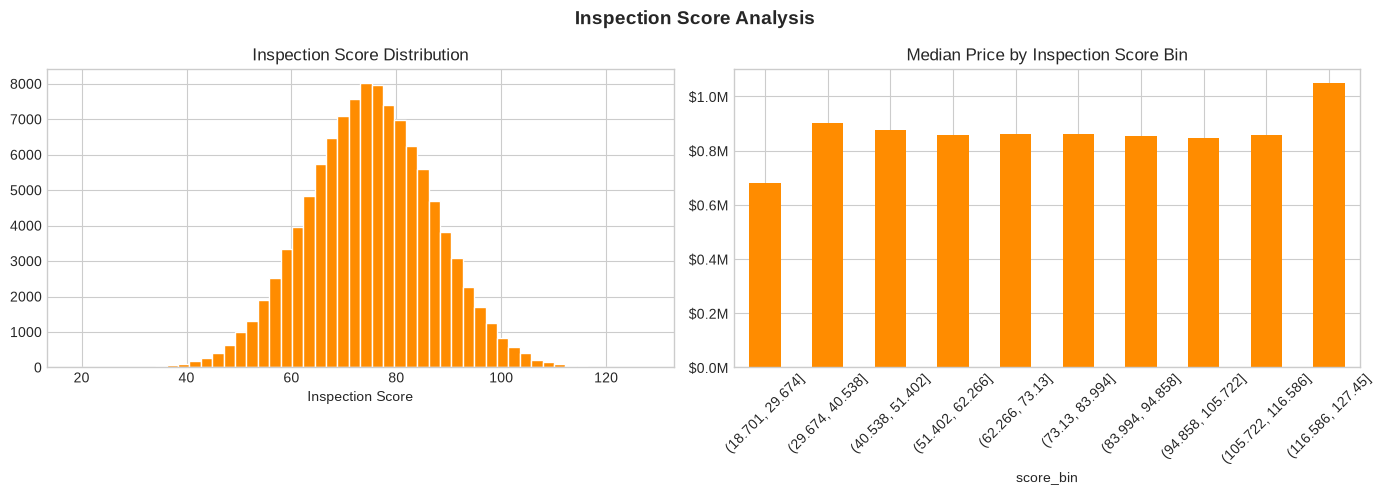

In [82]:
# inspection score might reflect building condition/quality
# checking if it actually tracks with sale price
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(clean['inspection_score'].dropna(), bins=50, color='darkorange', edgecolor='white')
axes[0].set_title('Inspection Score Distribution')
axes[0].set_xlabel('Inspection Score')

# bin scores and look at median price per bin
clean = clean.copy()
clean['score_bin'] = pd.cut(clean['inspection_score'], bins=10)
bin_price = clean.groupby('score_bin', observed=True)['sale_price'].median()
bin_price.plot(kind='bar', ax=axes[1], color='darkorange')
axes[1].set_title('Median Price by Inspection Score Bin')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Inspection Score Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# no clean linear relationship — mid-range scores sometimes show higher prices.
# the model will learn the interaction with borough on its own.


### 3.11 Neighborhood Index vs Price

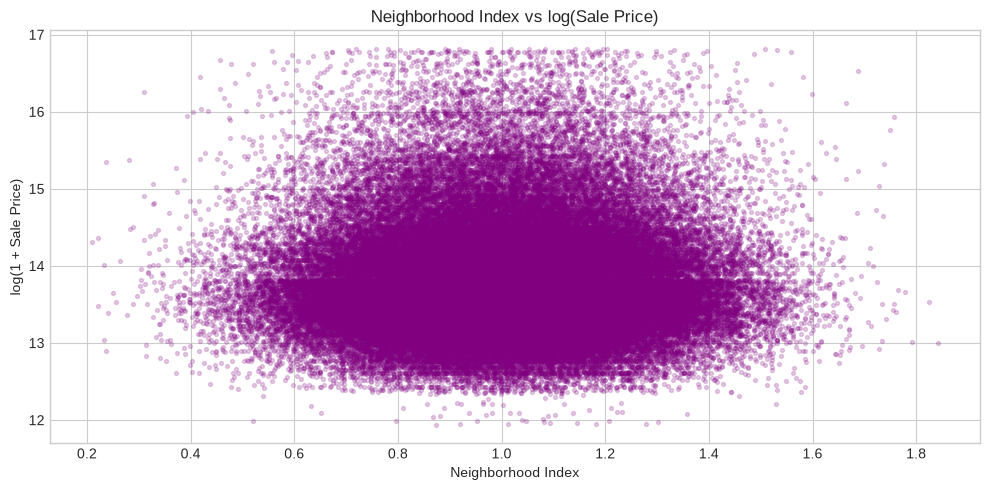

Pearson correlation (neighborhood_index vs price): 0.006


In [83]:
# a pre-computed neighborhood desirability score from the dataset
# checking whether it correlates with price
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(clean['neighborhood_index'], np.log1p(clean['sale_price']),
           alpha=0.2, s=8, color='purple')
ax.set_xlabel('Neighborhood Index')
ax.set_ylabel('log(1 + Sale Price)')
ax.set_title('Neighborhood Index vs log(Sale Price)')
plt.tight_layout()
plt.show()

corr2 = clean[['neighborhood_index', 'sale_price']].corr().iloc[0, 1]
print(f'Pearson correlation (neighborhood_index vs price): {corr2:.3f}')

# linear correlation looks low but tree models will pick up non-linear patterns.
# keeping this since it is a curated signal from the data provider.


### 3.12 Geographic Price Heatmap

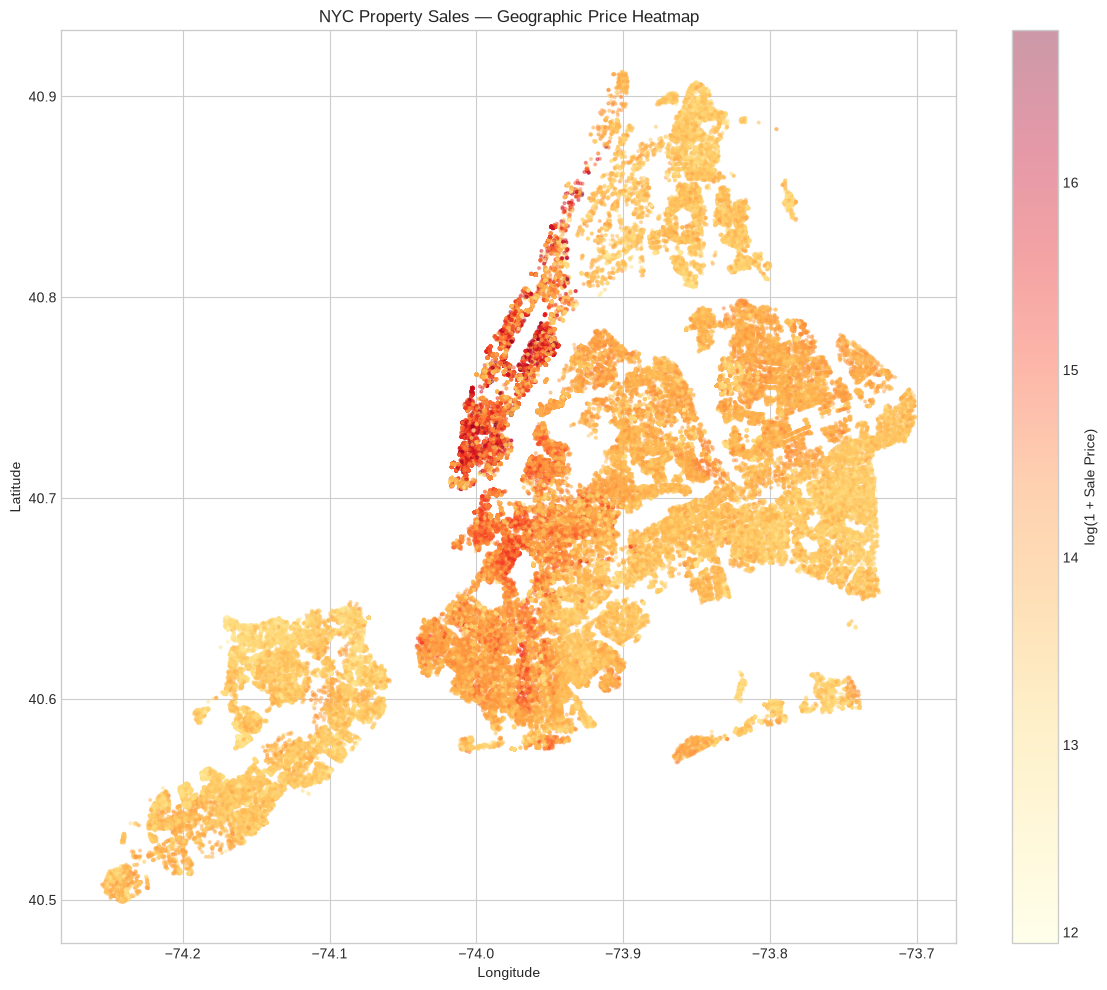

In [84]:
# plot every property on a map colored by log(price)
# location drives NYC real estate more than anything else
geo = clean.dropna(subset=['latitude', 'longitude'])
geo = geo[(geo['latitude']  > 40.4) & (geo['latitude']  < 41.0) &
          (geo['longitude'] > -74.3) & (geo['longitude'] < -73.6)]

fig, ax = plt.subplots(figsize=(12, 10))
sc = ax.scatter(geo['longitude'], geo['latitude'],
                c=np.log1p(geo['sale_price']), cmap='YlOrRd', s=4, alpha=0.4)
plt.colorbar(sc, ax=ax, label='log(1 + Sale Price)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('NYC Property Sales — Geographic Price Heatmap')
plt.tight_layout()
plt.show()

# Manhattan (center-top island) is clearly the most expensive.
# prices fade outward into Brooklyn, Queens, and the Bronx.
# lat/lon captures micro-neighborhood pricing that borough label alone misses.
# will also add distance-to-Midtown as a continuous location gradient feature.


### 3.13 Correlation Heatmap

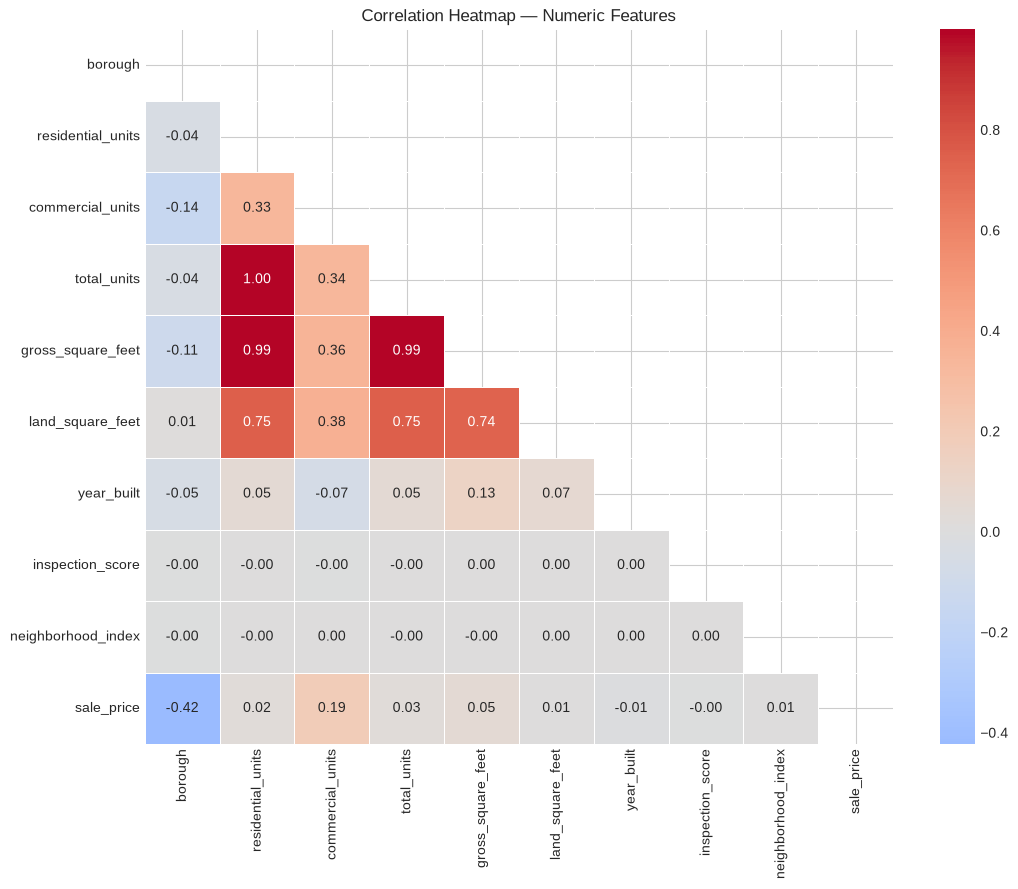

In [85]:
# quick look at linear correlations between numeric columns
# helps spot multicollinearity and what most directly relates to price
num_cols = ['borough', 'residential_units', 'commercial_units', 'total_units',
            'gross_square_feet', 'land_square_feet', 'year_built',
            'inspection_score', 'neighborhood_index', 'sale_price']

corr_matrix = clean[num_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, ax=ax, linewidths=0.5)
ax.set_title('Correlation Heatmap — Numeric Features')
plt.tight_layout()
plt.show()

# unit count columns are highly correlated with each other — fine for tree models.
# gross_square_feet has the strongest linear relationship with price.


## 4. Feature Engineering

In [86]:
# all feature creation in one function so train and test get identical treatment

def engineer_features(df):
    df = df.copy()

    # extract useful parts from the date — year and quarter matter most
    df['sale_year']    = df['sale_date'].dt.year
    df['sale_month']   = df['sale_date'].dt.month
    df['sale_quarter'] = df['sale_date'].dt.quarter

    # building age at time of sale — newer buildings tend to be pricier
    df['building_age'] = (df['sale_year'] - df['year_built']).clip(0, 300)

    # log-transform size — price-size relationship is multiplicative
    # fillna(0) → log(1)=0 for missing; the flag below tells model which were filled
    df['log_gross_sqft'] = np.log1p(df['gross_square_feet'].fillna(0))
    df['log_land_sqft']  = np.log1p(df['land_square_feet'].fillna(0))
    df['has_gross_sqft'] = df['gross_square_feet'].notna().astype(int)
    df['has_land_sqft']  = df['land_square_feet'].notna().astype(int)

    # sqft per unit — rough density signal
    df['sqft_per_unit'] = df['gross_square_feet'].fillna(0) / (df['total_units'].fillna(1) + 1)

    # distance to Midtown Manhattan (km) — continuous proxy for the price gradient
    # Haversine formula; ref point: 40.7549, -73.984
    lat  = df['latitude'].fillna(40.7549)
    lon  = df['longitude'].fillna(-73.984)
    dlat = np.radians(lat - 40.7549)
    dlon = np.radians(lon - (-73.984))
    a    = (np.sin(dlat / 2)**2 +
            np.cos(np.radians(40.7549)) * np.cos(np.radians(lat)) * np.sin(dlon / 2)**2)
    df['dist_to_manhattan'] = 6371.0 * 2 * np.arcsin(np.sqrt(a))

    # borough × building class combo — Manhattan condo ≠ Queens condo in price
    combo = df['borough'].astype(str) + '_' + df['building_class_at_time_of_sale'].astype(str).str.strip()
    df['borough_x_class_enc'] = LabelEncoder().fit_transform(combo)

    # zip code as numeric — some zip codes are dramatically more expensive
    df['zip_code_num'] = pd.to_numeric(df['zip_code'], errors='coerce')

    # label encode the lower-cardinality categoricals (no strong price ordering)
    for col in ['tax_class_at_time_of_sale', 'tax_class_as_of_final_roll',
                'building_class_as_of_final_roll']:
        df[col + '_enc'] = LabelEncoder().fit_transform(df[col].astype(str).str.strip())

    return df

train_fe = engineer_features(train)
test_fe  = engineer_features(test)
print(f'Columns after engineering: {train_fe.shape[1]}')


Columns after engineering: 37


## 5. Remove Outliers (Per-Borough Log IQR)

In [87]:
# apply the same per-borough log-IQR logic from EDA to the engineered dataframe.
# only on training data — test rows must stay in the order given.

train_valid = train_fe[train_fe['sale_price'] > 0].copy()
keep_mask   = pd.Series(True, index=train_valid.index)

for boro_id in train_valid['borough'].unique():
    m      = train_valid['borough'] == boro_id
    log_p  = np.log1p(train_valid.loc[m, 'sale_price'])
    Q1, Q3 = log_p.quantile(0.25), log_p.quantile(0.75)
    IQR    = Q3 - Q1
    lo, hi = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    keep_mask[m] = (log_p >= lo) & (log_p <= hi)

train_clean = train_valid[keep_mask]

removed = len(train_valid) - len(train_clean)
print(f'Removed {removed:,} rows ({removed / len(train_valid) * 100:.1f}%)')
print(f'Training rows remaining: {len(train_clean):,}')


Removed 3,843 rows (3.4%)
Training rows remaining: 108,927


## 6. Target Encoding for High-Cardinality Columns

In [88]:
# neighborhood has 248 unique values — label encoding assigns arbitrary integers
# that imply a fake ordering. instead: replace each category with its
# mean log(price) from training. directly tells the model 'how expensive
# is this neighborhood on average'.
# computed only on train_clean so no test data leaks into the encoding.

y_log       = np.log1p(train_clean['sale_price'])
global_mean = y_log.mean()

te_cols = {
    'neighborhood'                   : 'neighborhood_te',
    'zip_code'                       : 'zip_code_te',
    'building_class_category'        : 'building_class_category_te',
    'building_class_at_time_of_sale' : 'building_class_te',
}

for raw_col, enc_col in te_cols.items():
    # mean log-price per category, from training data only
    means = y_log.groupby(train_clean[raw_col].astype(str)).mean()
    train_clean = train_clean.copy()
    train_clean[enc_col] = train_clean[raw_col].astype(str).map(means).fillna(global_mean)
    # unseen test categories fall back to global mean
    test_fe[enc_col] = test_fe[raw_col].astype(str).map(means).fillna(global_mean)

print('Target encoding done:', list(te_cols.values()))


Target encoding done: ['neighborhood_te', 'zip_code_te', 'building_class_category_te', 'building_class_te']


## 7. Prepare Features for Model

In [89]:
FEATURE_COLS = [
    # location
    'borough', 'latitude', 'longitude', 'zip_code_num', 'dist_to_manhattan',
    # unit counts
    'residential_units', 'commercial_units', 'total_units',
    # size
    'log_gross_sqft', 'log_land_sqft', 'has_gross_sqft', 'has_land_sqft', 'sqft_per_unit',
    # age
    'year_built', 'building_age',
    # scores / index
    'inspection_score', 'neighborhood_index',
    # date
    'sale_year', 'sale_month', 'sale_quarter',
    # label-encoded
    'tax_class_at_time_of_sale_enc', 'tax_class_as_of_final_roll_enc',
    'building_class_as_of_final_roll_enc', 'borough_x_class_enc',
    # target-encoded (high-cardinality)
    'neighborhood_te', 'zip_code_te', 'building_class_category_te', 'building_class_te',
]

X      = train_clean[FEATURE_COLS]
y      = np.log1p(train_clean['sale_price'])   # train in log space, matches RMSLE
X_test = test_fe[FEATURE_COLS]

# fill leftover NaNs (year_built, lat/lon) with median
imputer    = SimpleImputer(strategy='median')
X_imp      = pd.DataFrame(imputer.fit_transform(X),      columns=FEATURE_COLS)
X_test_imp = pd.DataFrame(imputer.transform(X_test),     columns=FEATURE_COLS)

# 85/15 split — give the model more training rows
X_train, X_val, y_train, y_val = train_test_split(X_imp, y, test_size=0.15, random_state=42)
print(f'Train: {X_train.shape}   Val: {X_val.shape}   Features: {len(FEATURE_COLS)}')


Train: (92587, 28)   Val: (16340, 28)   Features: 28


## 8. Model Training

### 8.1 LightGBM

In [ ]:
# LightGBM — very fast gradient boosting, great on tabular data
# num_leaves=255 gives wide trees that capture complex interactions
# early stopping so we stop when validation loss stops improving

if LGB_AVAILABLE:
    lgb_model = lgb.LGBMRegressor(
        n_estimators=3000,
        learning_rate=0.03,
        num_leaves=255,
        subsample=0.8,
        colsample_bytree=0.7,
        min_child_samples=20,
        reg_alpha=0.05,
        reg_lambda=0.5,
        random_state=42,
        n_jobs=-1,
        verbose=-1,
    )
    lgb_model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[
            lgb.early_stopping(100, verbose=False),
            lgb.log_evaluation(200),
        ],
    )
    lgb_val   = lgb_model.predict(X_val)
    lgb_test  = lgb_model.predict(X_test_imp)
    rmsle_lgb = np.sqrt(np.mean((lgb_val - y_val) ** 2))
    print(f'\nLightGBM val RMSLE: {rmsle_lgb:.4f}')


### 8.2 XGBoost

In [ ]:
# XGBoost — slightly different internal structure to LightGBM,
# so its errors are less correlated, which helps when we average models later.
# needed 3000 trees — hadn't converged at 1000 in earlier runs.

if XGB_AVAILABLE:
    xgb_model = xgb.XGBRegressor(
        n_estimators=3000,
        learning_rate=0.03,
        max_depth=7,
        subsample=0.8,
        colsample_bytree=0.7,
        min_child_weight=5,
        reg_alpha=0.05,
        reg_lambda=0.5,
        random_state=42,
        n_jobs=-1,
        early_stopping_rounds=100,
        eval_metric='rmse',
    )
    xgb_model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=200,
    )
    xgb_val   = xgb_model.predict(X_val)
    xgb_test  = xgb_model.predict(X_test_imp)
    rmsle_xgb = np.sqrt(np.mean((xgb_val - y_val) ** 2))
    print(f'\nXGBoost val RMSLE: {rmsle_xgb:.4f}')


### 8.3 Random Forest

In [ ]:
# random forest as the third model — structurally different from boosted trees,
# so its errors are largely uncorrelated, which helps the average

rf_model = RandomForestRegressor(
    n_estimators=400,
    max_depth=25,
    min_samples_leaf=3,
    n_jobs=-1,
    random_state=42,
)
rf_model.fit(X_train, y_train)

rf_val   = rf_model.predict(X_val)
rf_test  = rf_model.predict(X_test_imp)
rmsle_rf = np.sqrt(np.mean((rf_val - y_val) ** 2))
print(f'Random Forest val RMSLE: {rmsle_rf:.4f}')


### 8.4 Model Comparison

In [ ]:
results = {'Random Forest': rmsle_rf}
if XGB_AVAILABLE: results['XGBoost']  = rmsle_xgb
if LGB_AVAILABLE: results['LightGBM'] = rmsle_lgb

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(list(results.keys()), list(results.values()),
              color=['steelblue', 'coral', 'teal'][:len(results)])
for bar, val in zip(bars, results.values()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
            f'{val:.4f}', ha='center', va='bottom', fontweight='bold')
ax.set_title('Validation RMSLE by Model (lower = better)')
ax.set_ylabel('RMSLE')
ax.set_ylim(0, max(results.values()) * 1.2)
plt.tight_layout()
plt.show()

best = min(results, key=results.get)
print(f'Best single model: {best}  (RMSLE = {results[best]:.4f})')


### 8.5 Ensemble (Simple Average)

In [ ]:
# average log-space predictions from all trained models.
# each model has different error patterns — averaging cancels some out.
# simple average works well enough here; no need for a stacking meta-model.

val_preds  = [rf_val]
test_preds = [rf_test]

if XGB_AVAILABLE:
    val_preds.append(xgb_val)
    test_preds.append(xgb_test)

if LGB_AVAILABLE:
    val_preds.append(lgb_val)
    test_preds.append(lgb_test)

ensemble_val  = np.mean(val_preds,  axis=0)
ensemble_test = np.mean(test_preds, axis=0)

rmsle_ensemble = np.sqrt(np.mean((ensemble_val - y_val) ** 2))
print(f'Ensemble val RMSLE          : {rmsle_ensemble:.4f}')
print(f'Improvement over best single: {results[best] - rmsle_ensemble:.4f}')


## 9. Feature Importance

In [ ]:
# which features does the model rely on most?
if LGB_AVAILABLE:
    imp = pd.Series(lgb_model.feature_importances_, index=FEATURE_COLS)
    title = 'LightGBM Feature Importance (top 20)'
elif XGB_AVAILABLE:
    imp = pd.Series(xgb_model.feature_importances_, index=FEATURE_COLS)
    title = 'XGBoost Feature Importance (top 20)'
else:
    imp = pd.Series(rf_model.feature_importances_, index=FEATURE_COLS)
    title = 'Random Forest Feature Importance (top 20)'

imp = imp.sort_values(ascending=True).tail(20)

fig, ax = plt.subplots(figsize=(10, 7))
imp.plot(kind='barh', ax=ax, color='teal')
ax.set_title(title)
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

# target-encoded columns typically dominate — they directly inject average price
# per category, which is the most informative single number per group.


## 10. Predicted vs Actual & Residuals

In [ ]:
# check how well ensemble predictions align with actual validation values
# and whether there is any systematic bias
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_val, ensemble_val, alpha=0.3, s=8, color='steelblue')
mn, mx = float(y_val.min()), float(y_val.max())
axes[0].plot([mn, mx], [mn, mx], 'r--', linewidth=1.5, label='Perfect')
axes[0].set_xlabel('Actual log(Price)')
axes[0].set_ylabel('Predicted log(Price)')
axes[0].set_title('Predicted vs Actual (ensemble)')
axes[0].legend()

residuals = ensemble_val - y_val
axes[1].hist(residuals, bins=60, color='coral', edgecolor='white')
axes[1].axvline(0, color='black', linestyle='--')
axes[1].axvline(residuals.mean(), color='red', linestyle='--',
                label=f'Mean = {residuals.mean():.3f}')
axes[1].set_xlabel('Residual (Predicted − Actual)')
axes[1].set_title('Residual Distribution')
axes[1].legend()

plt.suptitle('Model Diagnostics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Residual mean: {residuals.mean():.4f}')
print(f'Residual std : {residuals.std():.4f}')

# predictions cluster along the diagonal — low bias overall.
# slight right tail: model still under-predicts a few ultra-luxury properties,
# which is expected given how rare they are in training.


## 11. Save Predictions

In [ ]:
# convert log predictions back to dollar amounts
# clip negatives just in case — sale_price must be positive
final_prices = np.clip(np.expm1(ensemble_test), 1, None)

submission = pd.DataFrame({
    'id'         : test['id'],
    'sale_price' : final_prices
})

print(f'Rows       : {len(submission):,}')
print(f'Price range: ${submission["sale_price"].min():,.0f} — ${submission["sale_price"].max():,.0f}')
print(f'Median pred: ${submission["sale_price"].median():,.0f}')
submission.head(10)


In [ ]:
# sanity check — test prediction distribution should roughly match training prices.
# if they look very different something probably went wrong upstream.
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(np.log1p(train_clean['sale_price']), bins=80, alpha=0.5,
        label='Train actual', color='steelblue')
ax.hist(np.log1p(submission['sale_price']), bins=80, alpha=0.5,
        label='Test predicted', color='coral')
ax.set_xlabel('log(1 + Sale Price)')
ax.set_title('Train Actual vs Test Predictions')
ax.legend()
plt.tight_layout()
plt.show()


In [ ]:
import os
os.makedirs('submission', exist_ok=True)
submission.to_csv('submission/suggestion.csv', index=False)
print('Saved to submission/suggestion.csv')
print('Zip the submission folder manually when ready to upload.')
